# Day 6 — Noise Analysis Report
## Objective
Study three signal-quality effects: Additive White Gaussian Noise (AWGN), phase jitter, and spectral leakage. This notebook uses synthetic data only; it does not capture or analyze real-world RF transmissions.

## 1. Setup and clean signal
Create a synthetic 50 Hz sine wave sampled at 1000 samples per second. These values are for demonstration, not physical measurements.

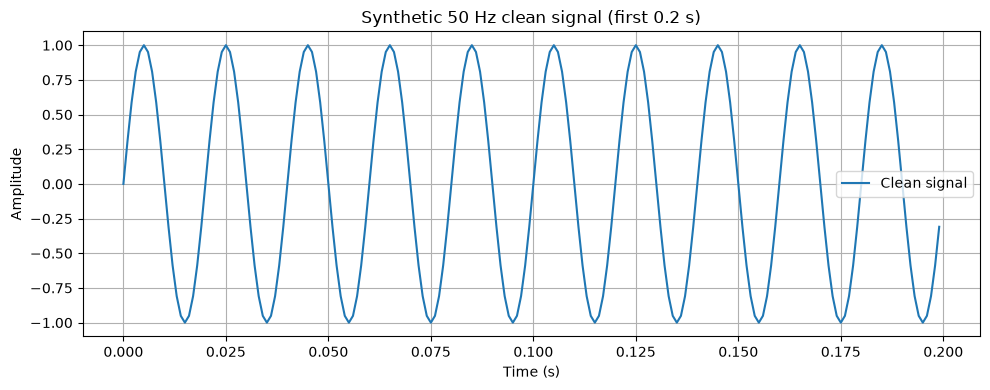

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000
duration = 1.0
t = np.arange(0, duration, 1/fs)
frequency = 50
amplitude = 1.0

clean_signal = amplitude * np.sin(2 * np.pi * frequency * t)

plt.figure(figsize=(10, 4))
plt.plot(t[:200], clean_signal[:200], label="Clean signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Synthetic 50 Hz clean signal (first 0.2 s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Experiment A — AWGN
**Method:** Add zero-mean Gaussian noise to the clean signal. The standard deviation is a configurable demonstration parameter.

Model: `noisy_signal = clean_signal + noise`

**Expected observation:** Larger noise standard deviation generally creates greater sample-to-sample variation.

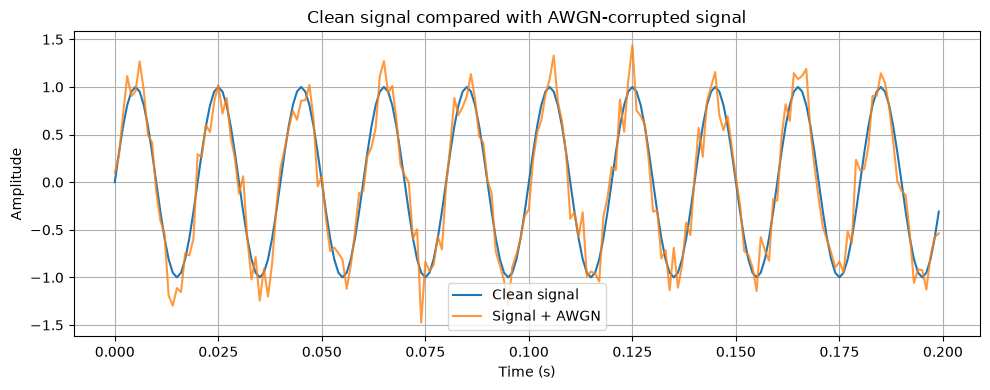

Signal power estimate: 0.5000
Noise power estimate:  0.0383
Measured SNR estimate: 11.15 dB


In [ ]:
np.random.seed(42)

noise_std = 0.2
noise = np.random.normal(0, noise_std, len(t))
noisy_signal = clean_signal + noise

plt.figure(figsize=(10, 4))
plt.plot(t[:200], clean_signal[:200], label="Clean signal")
plt.plot(t[:200], noisy_signal[:200], label="Signal + AWGN", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Clean signal compared with AWGN-corrupted signal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

signal_power = np.mean(clean_signal ** 2)
noise_power = np.mean(noise ** 2)
snr_db = 10 * np.log10(signal_power / noise_power)

print(f"Signal power estimate: {signal_power:.4f}")
print(f"Noise power estimate:  {noise_power:.4f}")
print(f"Measured SNR estimate: {snr_db:.2f} dB")

### AWGN interpretation
- **Additive:** Noise is added to the signal.
- **White:** Idealized noise has constant power spectral density over frequency.
- **Gaussian:** Noise samples are modeled using a normal distribution.
- SNR compares signal power with noise power. If signal power stays constant while noise power rises, SNR falls.

Power and SNR are finite-sample estimates; results can vary with the random sequence.

## 3. Experiment B — Phase jitter
**Method:** Add small random phase perturbations to the phase argument of the sine wave.

Model: `jittered_signal = A * sin(2*pi*f*t + phase_jitter)`

The phase-jitter standard deviation is an illustrative value in radians, not a hardware specification.

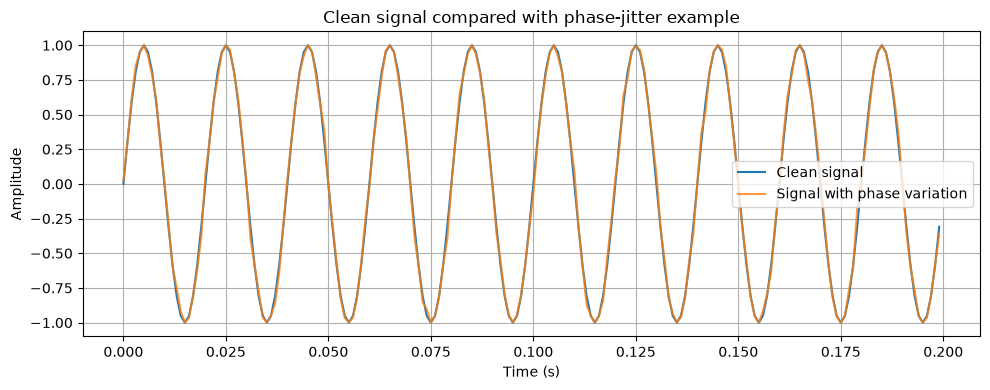

Configured phase-jitter standard deviation: 0.05 radians
Measured phase perturbation standard deviation: 0.0489 radians


In [3]:
np.random.seed(42)

phase_jitter_std = 0.05  # radians; illustrative only
phase_jitter = np.random.normal(0, phase_jitter_std, len(t))
jittered_signal = amplitude * np.sin(
    2 * np.pi * frequency * t + phase_jitter
)

plt.figure(figsize=(10, 4))
plt.plot(t[:200], clean_signal[:200], label="Clean signal")
plt.plot(t[:200], jittered_signal[:200], label="Signal with phase variation", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Clean signal compared with phase-jitter example")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Configured phase-jitter standard deviation: {phase_jitter_std} radians")
print(f"Measured phase perturbation standard deviation: {np.std(phase_jitter):.4f} radians")

### Phase-jitter interpretation
Phase jitter is unwanted variation in a signal's phase or timing. This simplified demonstration applies independent random phase perturbations at each sample. Real systems may have different temporal characteristics.

## 4. Experiment C — Spectral leakage
**Method:** Compare a 50 Hz tone, which completes an integer number of cycles in a one-second record, with a 50.5 Hz tone, which does not. A rectangular observation window can cause energy to spread across nearby FFT bins for the non-bin-centered tone.

A Hann window can reduce sidelobes, although it also broadens the main peak and changes amplitude scaling.

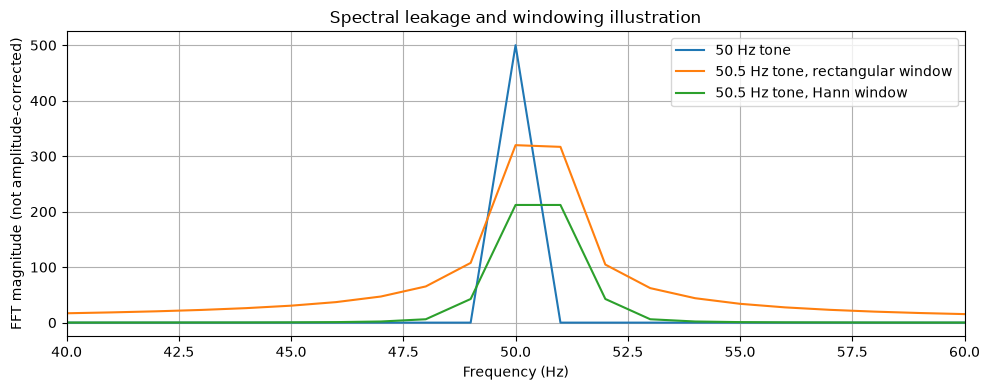

In [4]:
N = len(t)
signal_bin_centered = np.sin(2 * np.pi * 50.0 * t)
signal_non_bin_centered = np.sin(2 * np.pi * 50.5 * t)

freq = np.fft.rfftfreq(N, d=1/fs)
fft_centered = np.abs(np.fft.rfft(signal_bin_centered))
fft_non_centered = np.abs(np.fft.rfft(signal_non_bin_centered))

window = np.hanning(N)
fft_non_centered_hann = np.abs(np.fft.rfft(signal_non_bin_centered * window))

plt.figure(figsize=(10, 4))
plt.plot(freq, fft_centered, label="50 Hz tone")
plt.plot(freq, fft_non_centered, label="50.5 Hz tone, rectangular window")
plt.plot(freq, fft_non_centered_hann, label="50.5 Hz tone, Hann window")
plt.xlim(40, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT magnitude (not amplitude-corrected)")
plt.title("Spectral leakage and windowing illustration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Spectral-leakage interpretation
Spectral leakage is spreading of a tone's energy across multiple FFT bins due to observing a finite segment, especially when the tone does not align with an FFT bin. Windowing such as the Hann window can reduce sidelobes but does not remove all leakage; it trades lower sidelobes for a wider main lobe. FFT magnitudes here are not corrected for window gain.

## 5. Summary of observations

| Test | What was changed | Expected observation |
|---|---|---|
| AWGN | Added zero-mean Gaussian noise | Random variations appear in the waveform |
| Noise level | Increased noise standard deviation | Noise variations generally increase; with fixed signal power, SNR decreases as noise power increases |
| Phase jitter | Added random phase perturbations | The waveform's phase/timing varies |
| Spectral leakage | Compared bin-centered and non-bin-centered tones | Energy can spread across neighboring FFT bins |
| Hann window | Applied a Hann window | Sidelobes often decrease while the main lobe broadens |

## 6. Limitations
- All signals are synthetic and generated in software.
- The phase-jitter model is intentionally simple and is not a full model of oscillator phase noise.
- FFT magnitude is shown without window-gain correction.
- Results demonstrate concepts; they are not measurements or validation of physical RF equipment.

## 7. Conclusion
The experiments demonstrate how AWGN affects signal samples, how random phase variation changes a waveform, and how finite observation windows can produce spectral leakage in FFT analysis. This is a reproducible introductory noise-characterization report.